# Myanmar Wikipedia Control Map — Pixel-Accurate Ground Truth

Uses full raster rendering of each SVG + majority-color sampling within
each township polygon. This gives accurate labels matching exactly what
the Wikipedia map shows.

**Install dependencies first:**
```bash
uv add svglib reportlab rasterio
```

**Save SVGs from Wikimedia:**  
Go to https://commons.wikimedia.org/wiki/File:Myanmar_civil_war.svg  
Click each date in file history → right-click page → Save Page As → `.svg`  
Save as `myanmar_YYYY-MM-DD.svg` in `data/raw/wikipedia_snapshots/`


In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# svglib + reportlab for SVG → PNG (pure Python, no system deps)
from svglib.svglib import svg2rlg
from reportlab.graphics import renderPM
from PIL import Image

# rasterio for polygon-based pixel sampling
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize as rio_rasterize
from shapely.geometry import mapping

REPO_ROOT     = Path('..').resolve()
SNAPSHOTS_DIR = REPO_ROOT / 'data' / 'raw' / 'wikipedia_snapshots'
OUTPUT_CSV    = REPO_ROOT / 'data' / 'processed' / 'myanmar_control_labels.csv'
GADM_PATH     = REPO_ROOT / 'data' / 'raw' / 'gadm'
PNG_CACHE_DIR = SNAPSHOTS_DIR / 'png_cache'

PNG_CACHE_DIR.mkdir(parents=True, exist_ok=True)
(REPO_ROOT / 'data' / 'processed').mkdir(parents=True, exist_ok=True)
print("Ready")


Ready


## Color map — extracted from actual SVG file

In [2]:
# Colors extracted directly from Myanmar_civil_war.svg
# Identified by geographic position + Wikipedia legend
# Format: (R,G,B) tuple → (actor_name, broad_category)

COLOR_MAP_RGB = {
    # ── Tatmadaw / SAC (salmon-pink) ─────────────────────────────────────────
    (235,192,179): ('Tatmadaw',            'Junta'),
    (207,149,156): ('Tatmadaw',            'Junta'),
    (237,149,149): ('Tatmadaw',            'Junta'),
    (235,191,178): ('Tatmadaw',            'Junta'),
    (235,190,178): ('Tatmadaw',            'Junta'),
    (235,192,178): ('Tatmadaw',            'Junta'),
    (205,124,124): ('Tatmadaw',            'Junta'),
    (245,155,171): ('Tatmadaw',            'Junta'),
    (112, 51, 58): ('Tatmadaw',            'Junta'),

    # ── Contested / frontline (bright red) ───────────────────────────────────
    (255,  0,  0): ('Contested',           'Contested'),
    (214, 74, 74): ('Contested',           'Contested'),
    (255,127, 42): ('Contested',           'Contested'),

    # ── PDF / NUG (light green, central Myanmar) ─────────────────────────────
    (202,231,196): ('PDF',                 'Resistance'),
    (169,232,155): ('PDF',                 'Resistance'),

    # ── Kachin Independence Army (bright greens, N Myanmar) ──────────────────
    (204,234,221): ('Kachin Independence Army', 'Resistance'),
    (107,198,129): ('Kachin Independence Army', 'Resistance'),
    ( 35,197,  0): ('Kachin Independence Army', 'Resistance'),
    ( 69,235, 34): ('Kachin Independence Army', 'Resistance'),
    ( 33,143, 59): ('Kachin Independence Army', 'Resistance'),

    # ── Karen resistance (blues, Karen State E Myanmar) ───────────────────────
    (136,192,242): ('Karen resistance',    'Resistance'),
    (198,236,255): ('Karen resistance',    'Resistance'),
    ( 22,119,205): ('Karen resistance',    'Resistance'),

    # ── Arakan Army (yellows, Rakhine State) ─────────────────────────────────
    (243,235,165): ('Arakan Army',         'Resistance'),
    (226,226, 97): ('Arakan Army',         'Resistance'),
    (223,202,  8): ('Arakan Army',         'Resistance'),

    # ── Chin National Army / Brotherhood (greens, Chin State) ────────────────
    ( 77,182,137): ('Chin National Army',  'Resistance'),
    (193,231, 69): ('Chin Brotherhood',    'Resistance'),

    # ── MNDAA (orange, N Shan State) ─────────────────────────────────────────
    (229, 96, 68): ('MNDAA',               'Resistance'),

    # ── Mon Liberation Army (teals, Mon State) ───────────────────────────────
    (134,222,204): ('Mon Liberation Army', 'Resistance'),
    (  0,192,192): ('Mon Liberation Army', 'Resistance'),
    (150,239,239): ('Mon Liberation Army', 'Resistance'),

    # ── Pa-O NLA (purples, S Shan) ───────────────────────────────────────────
    (166,144,223): ('Pa-O NLA',            'Resistance'),
    (165,152,215): ('Pa-O NLA',            'Resistance'),
    (197,189,199): ('Pa-O NLA',            'Resistance'),

    # ── Karenni resistance (pink, Kayah State) ───────────────────────────────
    (232,153,183): ('Karenni resistance',  'Resistance'),
    (242,137,227): ('Danu forces',         'Resistance'),

    # ── SSA-North (grey-green, N Shan, non-combatant) ────────────────────────
    (184,184,171): ('SSA-North',           'Autonomous'),
    (187,187,168): ('SSA-North',           'Autonomous'),
    (141,149,145): ('SSA-South',           'Autonomous'),

    # ── UWSA (brownish grey, Wa State) ───────────────────────────────────────
    (204,215,210): ('UWSA',                'Other'),
    (183,157,157): ('UWSA',                'Other'),
    
    # SSA-North / non-combatant greys
(224,224,224): ('SSA-North',  'Autonomous'),  # #e0e0e0
(193,193,193): ('SSA-North',  'Autonomous'),  # #c1c1c1
(100,100,100): ('SSA-North',  'Autonomous'),  # #646464 (border lines — skip)
}

# Helper: find closest color by Euclidean distance in RGB space
def closest_color(rgb, tolerance=25):
    r, g, b = int(rgb[0]), int(rgb[1]), int(rgb[2])
    # Skip white, black, grey borders
    if r > 240 and g > 240 and b > 240: return None, None
    if r <  20 and g <  20 and b <  20: return None, None
    if abs(r-g) < 10 and abs(g-b) < 10 and r > 175: return None, None

    best_label, best_cat, best_d = 'Unknown', 'Unknown', float('inf')
    for ref, (label, cat) in COLOR_MAP_RGB.items():
        d = ((r-ref[0])**2 + (g-ref[1])**2 + (b-ref[2])**2) ** 0.5
        if d < best_d:
            best_d, best_label, best_cat = d, label, cat
    return (best_label, best_cat) if best_d <= tolerance else ('Unknown', 'Unknown')

print(f"Color map: {len(COLOR_MAP_RGB)} entries")
cats = Counter(v[1] for v in COLOR_MAP_RGB.values())
for cat, n in sorted(cats.items()):
    print(f"  {cat:12s}: {n} colors")


Color map: 44 entries
  Autonomous  : 6 colors
  Contested   : 3 colors
  Junta       : 9 colors
  Other       : 2 colors
  Resistance  : 24 colors


## SVG rendering

In [3]:
# Myanmar geographic bounds (calibrated to SVG coordinate system)
MMR = {
    'lon_min': 92.17, 'lon_max': 101.17,
    'lat_min':  9.78, 'lat_max':  28.55,
    'W': 1228, 'H': 2003,
}

def render_svg_to_png(svg_path, png_path):
    """Render SVG to PNG at native resolution using svglib."""
    if png_path.exists():
        return  # use cache
    drawing = svg2rlg(str(svg_path))
    renderPM.drawToFile(drawing, str(png_path), fmt='PNG', dpi=72, bg=0xFFFFFF)

def get_geotransform(img_array):
    img_h, img_w = img_array.shape[:2]
    return from_bounds(
        MMR['lon_min'], MMR['lat_min'],
        MMR['lon_max'], MMR['lat_max'],
        width=img_w, height=img_h
    )

def majority_color_in_polygon(img_array, polygon, transform):
    img_h, img_w = img_array.shape[:2]
    
    mask = rio_rasterize(
        [(mapping(polygon), 1)],
        out_shape=(img_h, img_w),
        transform=transform,
        fill=0,
        dtype='uint8'
    )
    ys, xs = np.where(mask == 1)
    if len(ys) == 0:
        return None

    # Clamp to actual image bounds
    ys = np.clip(ys, 0, img_h - 1)
    xs = np.clip(xs, 0, img_w - 1)

    pixels = img_array[ys, xs]

    valid = []
    for p in pixels:
        r, g, b = int(p[0]), int(p[1]), int(p[2])
        if r > 240 and g > 240 and b > 240: continue
        if r <  20 and g <  20 and b <  20: continue
        if abs(r-g) < 10 and abs(g-b) < 10 and r > 220: continue
        valid.append((r, g, b))

    if not valid:
        return None

    return Counter(valid).most_common(1)[0][0]

print("Rendering functions defined")


Rendering functions defined


## Load GADM township boundaries

In [4]:
gdf = gpd.read_file(GADM_PATH / 'gadm41_MMR.gpkg', layer='ADM_ADM_3')
gdf = gdf.loc[:, ~gdf.columns.duplicated()].copy()  # ← add this

col_map = {}
for col in gdf.columns:
    if 'NAME_3' in col: col_map[col] = 'township'
    elif 'NAME_2' in col: col_map[col] = 'district'
    elif 'NAME_1' in col: col_map[col] = 'state_region'
gdf = gdf.rename(columns=col_map).to_crs('EPSG:4326')

print(f"Loaded {len(gdf)} townships")
print(gdf[['township','state_region']].head(5))


Loaded 286 townships
       township township township state_region state_region
0  Bassein West       NA       NA   Ayeyarwady           NA
1     Kyaunggon       NA       NA   Ayeyarwady           NA
2      Kyonpyaw       NA       NA   Ayeyarwady           NA
3      Ngaputaw       NA       NA   Ayeyarwady           NA
4      Thabaung       NA       NA   Ayeyarwady           NA


In [5]:
# Nuclear fix for duplicate columns
gdf_fixed = gdf.copy()
# Get unique column names, keeping first occurrence
seen = {}
new_cols = []
for i, col in enumerate(gdf_fixed.columns):
    if col not in seen:
        seen[col] = i
        new_cols.append(col)
    else:
        new_cols.append(f'{col}_{i}')
gdf_fixed.columns = new_cols

# Keep only the columns we actually need
keep = ['township', 'state_region', 'district', 'geometry']
keep = [c for c in keep if c in gdf_fixed.columns]
gdf = gdf_fixed[keep].copy()

print("Columns:", list(gdf.columns))
print(f"Shape: {gdf.shape}")
print(gdf.head(3))

Columns: ['township', 'state_region', 'district', 'geometry']
Shape: (286, 4)
       township state_region district  \
0  Bassein West   Ayeyarwady  Bassein   
1     Kyaunggon   Ayeyarwady  Bassein   
2      Kyonpyaw   Ayeyarwady  Bassein   

                                            geometry  
0  MULTIPOLYGON (((94.27167 16.84613, 94.27141 16...  
1  MULTIPOLYGON (((95.22586 17.18739, 95.22499 17...  
2  MULTIPOLYGON (((95.22586 17.18739, 95.2197 17....  


## Process all SVG snapshots

In [6]:
EXPECTED_DATES = [
    '2023-12-30',
    '2024-01-09',
    '2024-04-04',
    '2024-08-09',
    '2024-11-10',
    '2025-01-05',
    '2025-04-04',
]

print("SVG snapshot status:")
available = []
for date in EXPECTED_DATES:
    p = SNAPSHOTS_DIR / f'myanmar_{date}.svg'
    if p.exists():
        print(f"  ✓  myanmar_{date}.svg")
        available.append((date, p))
    else:
        print(f"  ✗  myanmar_{date}.svg  ← save from Wikimedia file history")

print(f"\nReady: {len(available)} / {len(EXPECTED_DATES)}")


SVG snapshot status:
  ✓  myanmar_2023-12-30.svg
  ✓  myanmar_2024-01-09.svg
  ✓  myanmar_2024-04-04.svg
  ✓  myanmar_2024-08-09.svg
  ✓  myanmar_2024-11-10.svg
  ✓  myanmar_2025-01-05.svg
  ✓  myanmar_2025-04-04.svg

Ready: 7 / 7


In [8]:
all_records = []

for date, svg_path in available:
    # Render SVG to PNG (cached)
    png_path = PNG_CACHE_DIR / f'myanmar_{date}.png'
    print(f"{date}: rendering...", end=' ', flush=True)
    render_svg_to_png(svg_path, png_path)
    img_array = np.array(Image.open(png_path).convert('RGB'))
    transform = get_geotransform(img_array)
    print(f"done ({img_array.shape[1]}x{img_array.shape[0]}). Sampling townships...", end=' ', flush=True)

    n_unknown = 0
    for _, row in gdf.iterrows():
        twp      = row['township']
        state    = row.get('state_region', '')
        district = row.get('district', '')
        polygon  = row.geometry

        rgb = majority_color_in_polygon(img_array, polygon, transform)

        if rgb is None:
            actor, cat = 'Unknown', 'Unknown'
        else:
            actor, cat = closest_color(rgb)
            if actor == 'Unknown':
                n_unknown += 1

        all_records.append({
            'date':          date,
            'township':      twp,
            'state_region':  state,
            'district':      district,
            'control':       actor,
            'control_broad': cat,
        })

    cats = Counter(r['control_broad'] for r in all_records if r['date']==date)
    print({k:v for k,v in sorted(cats.items(), key=lambda x: str(x[0]))}, f"| {n_unknown} unmapped colors")
labels_df = pd.DataFrame(all_records)
labels_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✓ Saved {len(labels_df):,} records → {OUTPUT_CSV}")
print(labels_df['control_broad'].value_counts())


2023-12-30: rendering... done (921x1502). Sampling townships... {'Autonomous': 13, 'Contested': 1, 'Junta': 129, None: 10, 'Other': 1, 'Resistance': 111, 'Unknown': 21} | 18 unmapped colors
2024-01-09: rendering... done (921x1502). Sampling townships... {'Autonomous': 13, 'Contested': 3, 'Junta': 126, None: 9, 'Other': 1, 'Resistance': 112, 'Unknown': 22} | 19 unmapped colors
2024-04-04: rendering... done (921x1502). Sampling townships... {'Autonomous': 13, 'Contested': 4, 'Junta': 127, None: 11, 'Other': 1, 'Resistance': 123, 'Unknown': 7} | 4 unmapped colors
2024-08-09: rendering... done (921x1502). Sampling townships... {'Autonomous': 13, 'Contested': 3, 'Junta': 122, None: 13, 'Other': 1, 'Resistance': 125, 'Unknown': 9} | 6 unmapped colors
2024-11-10: rendering... done (921x1502). Sampling townships... {'Autonomous': 13, 'Contested': 3, 'Junta': 114, None: 14, 'Other': 1, 'Resistance': 133, 'Unknown': 8} | 5 unmapped colors
2025-01-05: rendering... done (921x1502). Sampling townsh

## Visualize

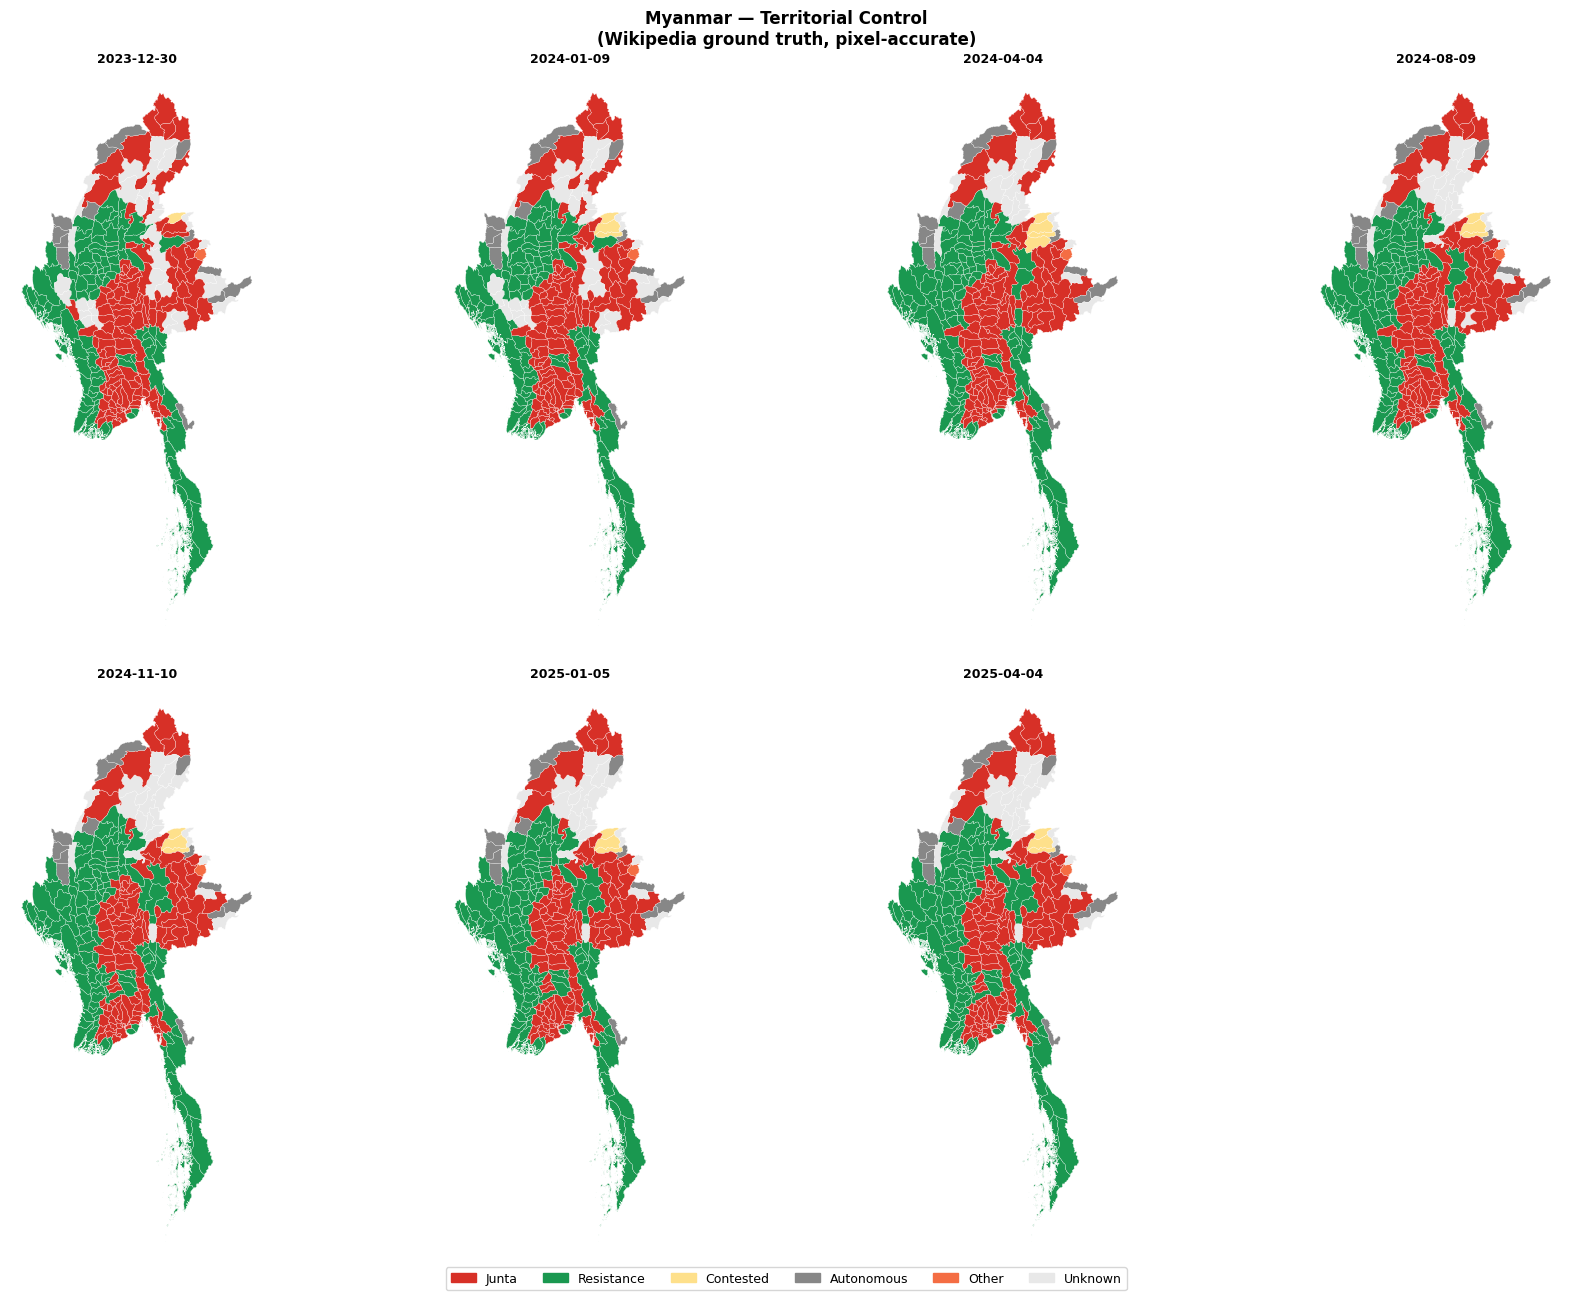

Saved → C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\reports\figures\myanmar_wiki_labels_v2.png


In [9]:
BROAD_COLORS = {
    'Junta':      '#d73027',
    'Resistance': '#1a9850',
    'Contested':  '#fee08b',
    'Autonomous': '#878787',
    'Other':      '#f46d43',
    'Unknown':    '#e8e8e8',
}

if 'labels_df' in dir() and len(labels_df) > 0:
    dates = sorted(labels_df['date'].unique())
    ncols = min(4, len(dates))
    nrows = -(-len(dates) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4.5, nrows*6.5))
    axes = np.array(axes).flatten()

    for i, date in enumerate(dates):
        ax     = axes[i]
        d_data = labels_df[labels_df['date']==date][['township','control_broad']]
        merged = gdf[['township','geometry']].merge(d_data, on='township', how='left')
        merged['control_broad'] = merged['control_broad'].fillna('Unknown')
        merged['color']         = merged['control_broad'].map(BROAD_COLORS).fillna('#e8e8e8')
        merged.plot(color=merged['color'], ax=ax, edgecolor='white', linewidth=0.2)
        ax.set_title(date, fontsize=9, fontweight='bold', pad=3)
        ax.set_axis_off()

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    patches = [mpatches.Patch(color=v, label=k) for k,v in BROAD_COLORS.items()]
    fig.legend(handles=patches, loc='lower center', ncol=6,
               fontsize=9, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle('Myanmar — Territorial Control\n(Wikipedia ground truth, pixel-accurate)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    out = REPO_ROOT / 'reports' / 'figures' / 'myanmar_wiki_labels_v2.png'
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved → {out}")


## Sanity checks

In [10]:
if 'labels_df' in dir() and len(labels_df) > 0:
    checks = [
        ('Naypyidaw',   'Junta capital — always Junta'),
        ('Lashio',      'MNDAA captured Aug 2024 — should flip'),
        ('Sagaing',     'Tatmadaw city — Junta'),
        ('Myawaddy',    'Karen resistance Apr 2024'),
        ('Sittwe',      'Arakan Army — should be Resistance'),
        ('Naypyitaw',   'try alternate spelling'),
    ]
    for twp, note in checks:
        sub = labels_df[labels_df['township'].str.contains(twp, case=False, na=False)]
        if len(sub) == 0:
            print(f"--- {twp}: not found ---\n")
            continue
        print(f"--- {twp} ({note}) ---")
        print(sub[['date','township','control','control_broad']].to_string(index=False))
        print()


--- Naypyidaw: not found ---

--- Lashio (MNDAA captured Aug 2024 — should flip) ---
      date township   control control_broad
2023-12-30   Lashio       PDF    Resistance
2024-01-09   Lashio       PDF    Resistance
2024-04-04   Lashio Contested     Contested
2024-08-09   Lashio  Tatmadaw         Junta
2024-11-10   Lashio  Tatmadaw         Junta
2025-01-05   Lashio  Tatmadaw         Junta
2025-04-04   Lashio  Tatmadaw         Junta

--- Sagaing (Tatmadaw city — Junta) ---
      date township  control control_broad
2023-12-30  Sagaing      PDF    Resistance
2024-01-09  Sagaing      PDF    Resistance
2024-04-04  Sagaing      PDF    Resistance
2024-08-09  Sagaing      PDF    Resistance
2024-11-10  Sagaing Tatmadaw         Junta
2025-01-05  Sagaing Tatmadaw         Junta
2025-04-04  Sagaing Tatmadaw         Junta

--- Myawaddy: not found ---

--- Sittwe (Arakan Army — should be Resistance) ---
      date       township          control control_broad
2023-12-30 Sittwe (Akyab) Karen resista

In [11]:
# Run this diagnostic cell
from collections import Counter
import numpy as np
from PIL import Image

# Load one rendered PNG
png_path = PNG_CACHE_DIR / 'myanmar_2025-04-04.png'
img = np.array(Image.open(png_path).convert('RGB'))

# Check unknown townships - what colors are actually there?
unknown_twps = labels_df[
    (labels_df['date'] == '2025-04-04') & 
    (labels_df['control_broad'] == 'Unknown')
]['township'].tolist()

print(f"Unknown townships: {len(unknown_twps)}")
print("\nSampling colors at unknown township centroids:")

transform = get_geotransform(img)

for twp in unknown_twps[:10]:
    row = gdf[gdf['township'] == twp].iloc[0]
    from rasterio.features import rasterize as rio_rasterize
    from shapely.geometry import mapping
    img_h, img_w = img.shape[:2]
    mask = rio_rasterize(
        [(mapping(row.geometry), 1)],
        out_shape=(img_h, img_w),
        transform=transform,
        fill=0, dtype='uint8'
    )
    ys, xs = np.where(mask == 1)
    if len(ys) == 0:
        print(f"  {twp}: NO PIXELS IN POLYGON")
        continue
    pixels = img[np.clip(ys,0,img_h-1), np.clip(xs,0,img_w-1)]
    valid = [tuple(c) for c in pixels
             if not (c[0]>240 and c[1]>240 and c[2]>240)
             and not (c[0]<20 and c[1]<20 and c[2]<20)]
    if valid:
        top = Counter(valid).most_common(3)
        print(f"  {twp}: {[f'#{c[0]:02x}{c[1]:02x}{c[2]:02x}({n})' for c,n in top]}")
    else:
        print(f"  {twp}: only white/black pixels")

Unknown townships: 8

Sampling colors at unknown township centroids:
  Lashe: ['#e0e0e0(1804)', '#89bed5(3)', '#8abed6(3)']
  Tamu: ['#e0e0e0(1171)', '#a9cad9(3)', '#d3dbde(3)']
  Mongkhak: ['#e0e0e0(1270)', '#d8abe7(261)', '#646464(139)']
  Kunlong: ['#e0e0e0(599)']
  Pangwaum: ['#e0e0e0(876)', '#a0c7d9(3)', '#dadedf(3)']
  Kong-Kyan: ['#e0e0e0(804)']
  Tachilek: ['#e0e0e0(2487)']
  Hsi Hseng: ['#c190df(434)', '#e899b7(356)', '#ebc0b3(280)']
